In [1]:
from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np


In [2]:
from pathlib import Path
import pandas as pd

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)
    return p

def read_csv(path: str | Path, **kw) -> pd.DataFrame:
    return pd.read_csv(path, **kw)

def to_parquet(df, path: str | Path):
    path = Path(path)
    ensure_dir(path.parent)
    df.to_parquet(path, index=False)
    return str(path)


# Load metadata

In [4]:
metadata_1 = r"/content/export_arh_11-20-final.csv"
df_metadata_1 = pd.read_csv(metadata_1, on_bad_lines='skip') # Directly use pd.read_csv with error handling
df_metadata_1.head()

,channel_id,channel_title,start_time,duration,tv_show_title,tv_show_id,tv_show_category,tv_show_genre_1,tv_show_genre_2,tv_show_genre_3,year_of_production,director,actors
0,3,1+1,09.03.2020 06:00:00,6000,"'Жизнь известных людей', 2 сезон.",0,Другое,NaN,NaN,NaN,NaN,NaN,NaN
1,3,1+1,09.03.2020 07:40:00,5400,'ТСН. Неделя'.,2400480,Инфо,общество и политика,NaN,NaN,1997,NaN,NaN
2,3,1+1,09.03.2020 09:10:00,8400,"'Голос страны', 10 сезон, 8 эп. 'Бои'.",700475,Развлечения,музыка,NaN,NaN,2010,NaN,NaN
3,3,1+1,09.03.2020 11:30:00,28800,"Т/с 'По праву любви', 1-8 с.",0,Сериалы,NaN,NaN,NaN,NaN,NaN,NaN
4,3,1+1,09.03.2020 19:30:00,2700,ТСН.,2400480,Инфо,общество и политика,NaN,NaN,1997,NaN,NaN


In [5]:
metadata_2 = r"/content/export_arh_21-30-final.csv"
df_metadata_2 = read_csv(metadata_2)
df_metadata_2.head()

,channel_id,channel_title,start_time,duration,tv_show_title,tv_show_id,tv_show_category,tv_show_genre_1,tv_show_genre_2,tv_show_genre_3,year_of_production,director,actors
0,3,1+1,18.05.2020 06:30:00,1800,'Завтрак с 1+1'. Информационно-развлекательная...,20088,Развлечения,информация (комплексная),NaN,NaN,1996-,NaN,NaN
1,3,1+1,18.05.2020 07:00:00,600,ТСН.,2400480,Инфо,общество и политика,NaN,NaN,1997,NaN,NaN
2,3,1+1,18.05.2020 07:10:00,3000,'Завтрак с 1+1'. Информационно-развлекательная...,20088,Развлечения,информация (комплексная),NaN,NaN,1996-,NaN,NaN
3,3,1+1,18.05.2020 08:00:00,600,ТСН.,2400480,Инфо,общество и политика,NaN,NaN,1997,NaN,NaN
4,3,1+1,18.05.2020 08:10:00,3000,'Завтрак с 1+1'. Информационно-развлекательная...,20088,Развлечения,информация (комплексная),NaN,NaN,1996-,NaN,NaN


In [6]:
df_metadata_2.columns

Index(['channel_id', 'channel_title', 'start_time', 'duration',
       'tv_show_title', 'tv_show_id', 'tv_show_category', 'tv_show_genre_1',
       'tv_show_genre_2', 'tv_show_genre_3', 'year_of_production', 'director',
       'actors'],
      dtype='object')

In [7]:
# Metadata (export_arh_*)
def _parse_meta_start(series: pd.Series) -> pd.Series:
    """
    Parse start_time của metadata. Ưu tiên định dạng 'dd.mm.YYYY HH:MM:SS'.
    Fallback sang dayfirst=True nếu không khớp.
    """
    try:
        return pd.to_datetime(series, format="%d.%m.%Y %H:%M:%S", errors="raise")
    except Exception:
        return pd.to_datetime(series, dayfirst=True, errors="raise")

def load_meta(paths: list[str | Path]) -> pd.DataFrame:
    """
    Đọc và gộp các file export_arh_11-20-final.csv, export_arh_21-30-final.csv.
    - Đổi channel_id -> vsetv_id
    - Parse start_time (định dạng dd.mm.YYYY HH:MM:SS)
    - Tính prog_end = start_time + duration(s)
    - Trả về các cột cần cho interval join
    """
    if not paths:
        raise ValueError("`paths` for metadata is empty.")

    dfs = [read_csv(p) for p in paths]
    meta = pd.concat(dfs, ignore_index=True).copy()

    # Đổi tên cột & kiểm tra
    meta = meta.rename(columns={"channel_id": "vsetv_id"})
    required = {"vsetv_id", "start_time", "duration", "tv_show_id"}
    missing = required - set(meta.columns)
    if missing:
        raise ValueError(f"Missing columns in meta: {missing}")

    # Parse time + duration
    meta["start_time"] = _parse_meta_start(meta["start_time"])
    meta["duration"] = pd.to_numeric(meta["duration"], errors="coerce").fillna(0).astype(int)
    meta["prog_end"] = meta["start_time"] + pd.to_timedelta(meta["duration"], unit="s")

    # Cột text có thể vắng -> fill
    for c in ["tv_show_title", "tv_show_category", "tv_show_genre_1", "tv_show_genre_2", "tv_show_genre_3"]:
        if c not in meta.columns:
            meta[c] = ""

    # BẮT BUỘC: loại show không liên quan
    meta = meta[meta["tv_show_id"] != 0].copy()

    cols = [
        "vsetv_id", "channel_title", "start_time", "prog_end","duration",
        "tv_show_title", "tv_show_id", "tv_show_category",
        "tv_show_genre_1", "tv_show_genre_2", "tv_show_genre_3",
        "year_of_production",	"director",	"actors"
    ]
    return meta[cols]


In [8]:
metadatas = []
metadatas.append(metadata_1)
metadatas.append(metadata_2)
meta = load_meta(metadatas)

In [9]:
meta.head

<bound method NDFrame.head of          vsetv_id        channel_title          start_time  \
1               3                  1+1 2020-03-09 07:40:00   
2               3                  1+1 2020-03-09 09:10:00   
4               3                  1+1 2020-03-09 19:30:00   
5               3                  1+1 2020-03-09 20:15:00   
6               3                  1+1 2020-03-10 00:10:00   
...           ...                  ...                 ...   
2147641      1528  ViP Premiere CEE HD 2020-07-26 23:05:00   
2147642      1528  ViP Premiere CEE HD 2020-07-27 00:40:00   
2147643      1528  ViP Premiere CEE HD 2020-07-27 02:50:00   
2147644      1528  ViP Premiere CEE HD 2020-07-27 04:15:00   
2147645      1528  ViP Premiere CEE HD 2020-07-27 05:50:00   

                   prog_end  duration  \
1       2020-03-09 09:10:00      5400   
2       2020-03-09 11:30:00      8400   
4       2020-03-09 20:15:00      2700   
5       2020-03-10 00:10:00     14100   
6       2020-03-10 02:05:00      6900   
...                     ...       ...   
2147641 2020-07-27 00:40:00      5700   
2147642 2020-07-27 02:50:00      7800   
2147643 2020-07-27 04:15:00      5100   
2147644 2020-07-27 05:50:00      5700   
2147645 2020-07-27 07:00:00      4200   

                                     tv_show_title  tv_show_id  \
1                                   'ТСН. Неделя'.     2400480   
2           'Голос страны', 10 сезон, 8 эп. 'Бои'.      700475   
4                                             ТСН.     2400480   
5        Премьера. Х/ф 'Любовь без памяти', 1-4 с.    90082508   
6                         Х/ф 'Сделано в Америке'.    90080911   
...                                            ...         ...   
2147641      Х/ф 'Уиджи. Проклятие доски дьявола'.    90080040   
2147642    Х/ф 'Человек, который убил Дон Кихота'.    90081769   
2147643          Х/ф 'Тебя никогда здесь не было'.    90081274   
2147644                             М/ф 'Смолфут'.   120082361   
2147645               Х/ф 'Помешанный на времени'.    90081718   

        tv_show_category      tv_show_genre_1 tv_show_genre_2 tv_show_genre_3  \
1                   Инфо  общество и политика             NaN             NaN   
2            Развлечения               музыка             NaN             NaN   
4                   Инфо  общество и политика             NaN             NaN   
5                 Фильмы            мелодрама             NaN             NaN   
6                 Фильмы               боевик  биографический         комедия   
...                  ...                  ...             ...             ...   
2147641           Фильмы              ужастик         триллер             NaN   
2147642           Фильмы              комедия           драма     приключения   
2147643           Фильмы                драма        криминал         триллер   
2147644            Детям          приключения         комедия          мюзикл   
2147645           Фильмы              комедия       мелодрама      фантастика   

        year_of_production         director  \
1                     1997              NaN   
2                     2010              NaN   
4                     1997              NaN   
5                     2019   Андрей Комаров   
6                     2017       Даг Лаймэн   
...                    ...              ...   
2147641               2016    Майк Флэнэгэн   
2147642               2018    Терри Гиллиам   
2147643               2017       Линн Рэмси   
2147644               2018  Кэри Кёркпатрик   
2147645               2018     Эндрю Баулер   

                                                   actors  
1                                                     NaN  
2                                                     NaN  
4                                                     NaN  
5                  Алина Гросу, Артем Алексеев, Ирина Мак  
6                       Том Круз, Донал Глисон, Сара Райт  
...                                      

In [ ]:
# nếu đang ở trong venv
!python -m pip install --upgrade pip
!python -m pip install matplotlib


   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 5.4 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.2
    Uninstalling pip-25.2:
      Successfully uninstalled pip-25.2
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 4.8 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.1 MB 5.3 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.1 MB 5.6 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.1 MB 5.5 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 5.2 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 5.0 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 4.9 MB/s eta 0:00:01
   -------------------------------------- - 

Tóm tắt duration (phút)
count    237118.000000
mean         55.743672
std          49.984150
min           1.000000
25%          20.000000
50%          45.000000
75%          90.000000
90%         120.000000
95%         140.000000
99%         225.000000
max         545.000000
Name: duration, dtype: float64


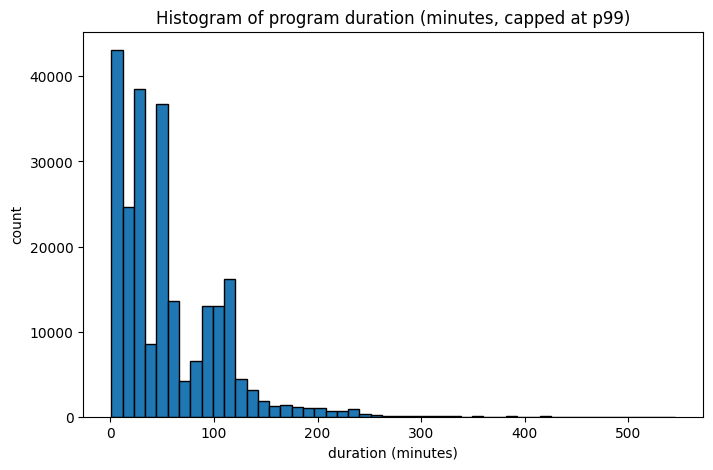

In [10]:
import matplotlib.pyplot as plt

# 2) Làm sạch & chuẩn bị dữ liệu vẽ
dur = pd.to_numeric(meta["duration"], errors="coerce")
dur = dur[dur > 0].dropna()                 # chỉ giữ duration dương
dur_min = dur / 60.0                        # đổi sang phút

print("Tóm tắt duration (phút)")
print(dur_min.describe(percentiles=[.25,.5,.75,.9,.95,.99]))

# 3) Vẽ histogram duration (phút) – p99 clipped
plt.figure(figsize=(8,5))
plt.hist(dur_min, bins=50, edgecolor="black")
plt.title("Histogram of program duration (minutes, capped at p99)")
plt.xlabel("duration (minutes)")
plt.ylabel("count")
plt.show()

# Load file logs

In [11]:
logs = r"/content/dataset11-30.csv"
df_logs = read_csv(logs)
df_logs.head()

,user_id,vsetv_id,start_time,stop_time,duraton
0,3398461054087191302,6,2020-03-09 00:00:02,2020-03-09 00:01:53,111
1,17226860011138219284,353,2020-03-09 00:00:02,2020-03-09 00:03:26,204
2,18417531283109304442,332,2020-03-09 00:00:05,2020-03-09 00:01:26,81
3,3677642666679759206,7,2020-03-09 00:00:08,2020-03-09 01:07:41,4053
4,15105343836194894915,108,2020-03-09 00:00:10,2020-03-09 00:02:34,144


In [17]:
df_logs.describe

<bound method NDFrame.describe of                       user_id  vsetv_id           start_time  \
0         3398461054087191302         6  2020-03-09 00:00:02   
1        17226860011138219284       353  2020-03-09 00:00:02   
2        18417531283109304442       332  2020-03-09 00:00:05   
3         3677642666679759206         7  2020-03-09 00:00:08   
4        15105343836194894915       108  2020-03-09 00:00:10   
...                       ...       ...                  ...   
5821982  13571199046623737884      1528  2020-07-26 23:58:01   
5821983   2838730117582047512      1174  2020-07-26 23:58:31   
5821984  13614421313501894974         3  2020-07-26 23:58:34   
5821985   7072476312452226836        19  2020-07-26 23:58:39   
5821986  13866173795451203812       403  2020-07-26 23:58:42   

                   stop_time  duraton  
0        2020-03-09 00:01:53      111  
1        2020-03-09 00:03:26      204  
2        2020-03-09 00:01:26       81  
3        2020-03-09 01:07:41     4053  
4        2020-03-09 00:02:34      144  
...                      ...      ...  
5821982  2020-07-26 23:59:58      117  
5821983  2020-07-26 23:59:36       65  
5821984  2020-07-26 23:59:54       80  
5821985  2020-07-26 23:59:50       71  
5821986  2020-07-26 23:59:45       63  

[5821987 rows x 5 columns]>

In [12]:
def load_logs(path: str | Path, min_duration_sec: int = 180) -> pd.DataFrame:
    """
    Đọc file logs (dataset11-30.csv), chuẩn hoá cột và lọc lượt xem ngắn.
    - Đổi tên: stop_time->end_time, duraton->duration
    - Parse datetime cho start_time, end_time
    - Lọc duration >= min_duration_sec (min_duration_sec >= 80% program duration)
    """
    df = read_csv(path)
    df = df.rename(columns={"stop_time": "end_time", "duraton": "duration"}).copy()

    # Bắt buộc có các cột tối thiểu
    required = {"user_id", "vsetv_id", "start_time", "end_time", "duration"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in logs: {missing}")

    # Parse datetime cho logs (thường đã ở dạng ISO)
    df["start_time"] = pd.to_datetime(df["start_time"], errors="raise", utc=False)
    df["end_time"]   = pd.to_datetime(df["end_time"],   errors="raise", utc=False)

    # Duration numeric & filter
    df["duration"] = pd.to_numeric(df["duration"], errors="coerce").fillna(0).astype(int)
    df = df[df["duration"] >= int(min_duration_sec)].reset_index(drop=True)

    # Đổi tên cột nhất quán downstream
    df = df.rename(columns={
        "start_time": "start_time_view",
        "end_time":   "end_time_view",
        "duration":   "duration_view",
    })
    return df[["user_id", "vsetv_id", "start_time_view", "end_time_view", "duration_view"]]


In [13]:
log = load_logs(logs)

In [14]:
log.head

<bound method NDFrame.head of                       user_id  vsetv_id     start_time_view  \
0        17226860011138219284       353 2020-03-09 00:00:02   
1         3677642666679759206         7 2020-03-09 00:00:08   
2        18081325105171528512       921 2020-03-09 00:00:11   
3         8504965706466181080      1249 2020-03-09 00:00:13   
4         7072476312452226836       777 2020-03-09 00:00:13   
...                       ...       ...                 ...   
3927541   3473913935630829347        39 2020-07-26 23:55:15   
3927542  10013871288730343419        19 2020-07-26 23:55:17   
3927543   9451216938908035701       921 2020-07-26 23:55:36   
3927544   8639440216155909597       652 2020-07-26 23:55:40   
3927545   5201886213552257351         7 2020-07-26 23:55:49   

              end_time_view  duration_view  
0       2020-03-09 00:03:26            204  
1       2020-03-09 01:07:41           4053  
2       2020-03-09 00:05:41            330  
3       2020-03-09 00:32:58           1965  
4       2020-03-09 01:11:53           4300  
...                     ...            ...  
3927541 2020-07-26 23:59:16            241  
3927542 2020-07-26 23:59:18            241  
3927543 2020-07-26 23:59:57            261  
3927544 2020-07-26 23:59:01            201  
3927545 2020-07-26 23:59:15            206  

[3927546 rows x 5 columns]>

# Ghép log ↔ lịch phát sóng theo kênh + khoảng thời gian (interval join)
- logs: mỗi dòng là một lượt xem của user trên một kênh (vsetv_id) với khoảng thời gian [start_time_view, end_time_view].
- meta: lịch phát sóng của cùng kênh, mỗi dòng là một tập/chương trình với khoảng thời gian [start_time, prog_end].
- Mục tiêu: với mỗi lượt xem, tìm một chương trình trong lịch phát sóng trên cùng kênh mà chồng lấn (overlap) với lượt xem lớn nhất, rồi gán tv_show_id cho lượt xem đó.
![Alt text](image.png)

In [15]:
from __future__ import annotations
import argparse
from pathlib import Path
import numpy as np
import pandas as pd

In [20]:
def _pick_overlap(logs_ch: pd.DataFrame, meta_ch: pd.DataFrame) -> pd.DataFrame:
    """
    Với mỗi lượt xem (view) trên 1 kênh:
      - Chẻ view theo ranh giới chương trình trong meta_ch (đã sort theo start_time).
      - Trả về nhiều hàng (segment) cho một view nếu view bắc cầu >1 show.
    Yêu cầu meta_ch có các cột: ["vsetv_id","start_time","prog_end","tv_show_id"]
    và đã lọc tv_show_id != 0 từ trước.
    """
    if logs_ch.empty or meta_ch.empty:
        return pd.DataFrame(columns=[
            "user_id","tv_show_id","vsetv_id",
            "start_time_view","end_time_view","duration_view",
            "seg_start","seg_end","overlap_s","show_duration_s",
            "view_id","seg_idx"
        ])

    # Bảo đảm sort theo start_time để tìm kiếm nhị phân
    meta_ch = meta_ch.sort_values("start_time").reset_index(drop=True)

    # Chuẩn bị mảng nhanh
    # MẢNG NHANH – ép kiểu an toàn
    m_start = meta_ch["start_time"].to_numpy(dtype="datetime64[ns]")
    m_end   = meta_ch["prog_end"].to_numpy(dtype="datetime64[ns]")
    m_tid   = pd.to_numeric(meta_ch["tv_show_id"], errors="coerce").to_numpy()
    m_tid   = np.ravel(m_tid)  # phẳng 1-D

    # Gán view_id
    logs_ch = logs_ch.copy()
    logs_ch["view_id"] = np.arange(len(logs_ch), dtype=np.int64)

    out_rows = []
    for _, row in logs_ch.iterrows():
        v_start = np.datetime64(row["start_time_view"])
        v_end   = np.datetime64(row["end_time_view"])
        if v_end <= v_start:
            continue

        # Tìm show có start_time <= v_start (vị trí bắt đầu duyệt)
        # searchsorted trả vị trí chèn để giữ m_start tăng dần
        # side='right' rồi -1 để lấy phần tử <= v_start
        i = np.searchsorted(m_start, v_start, side="right") - 1
        if i < 0:
            i = 0

        seg_idx = 0
        # Duyệt các show cho đến khi start_time_show >= v_end
        # (vì những show bắt đầu sau v_end sẽ không thể overlap)
        n = len(meta_ch)
        while i < n and m_start[i] < v_end:
            s_show = m_start[i]
            e_show = m_end[i]
            # Nếu show kết thúc trước v_start thì nhảy tiếp
            if e_show <= v_start:
                i += 1
                continue
            # Nếu show bắt đầu sau v_end thì dừng
            if s_show >= v_end:
                break

            # Tính đoạn overlap giữa view và show
            seg_start = max(v_start, s_show)
            seg_end   = min(v_end, e_show)
            if seg_end > seg_start:
                overlap_s = int((seg_end - seg_start) / np.timedelta64(1, "s"))
                show_duration_s = int((e_show - s_show) / np.timedelta64(1, "s"))

                # LẤY tv_show_id an toàn
                tid_val = m_tid[i]
                if isinstance(tid_val, (np.ndarray, list)):
                    tid_val = np.ravel(tid_val)[0]
                if pd.isna(tid_val):
                    i += 1
                    continue
                tid_val = int(tid_val)

                out_rows.append({
                    "user_id": row["user_id"],
                    "tv_show_id": int(m_tid[i]),
                    "vsetv_id": row["vsetv_id"],
                    "start_time_view": row["start_time_view"],
                    "end_time_view": row["end_time_view"],
                    "duration_view": row["duration_view"],
                    "seg_start": pd.Timestamp(seg_start),
                    "seg_end": pd.Timestamp(seg_end),
                    "overlap_s": overlap_s,
                    "show_duration_s": show_duration_s,
                    "view_id": row["view_id"],
                    "seg_idx": seg_idx,
                })
                seg_idx += 1

            # Sang show kế tiếp
            i += 1

    if not out_rows:
        return pd.DataFrame(columns=[
            "user_id","tv_show_id","vsetv_id",
            "start_time_view","end_time_view","duration_view",
            "seg_start","seg_end","overlap_s","show_duration_s",
            "view_id","seg_idx"
        ])
    return pd.DataFrame(out_rows)

def interval_join_logs_with_program(logs: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    out = []
    for vid, logs_ch in logs.groupby("vsetv_id", sort=False):
        meta_ch = meta[meta["vsetv_id"] == vid]
        matched = _pick_overlap(logs_ch, meta_ch)
        if not matched.empty:
            out.append(matched)
    if not out:
        return pd.DataFrame(columns=[
            "user_id","tv_show_id","vsetv_id",
            "start_time_view","end_time_view","duration_view",
            "seg_start","seg_end","overlap_s","show_duration_s",
            "view_id","seg_idx"
        ])
    return pd.concat(out, ignore_index=True)


In [21]:
joined = interval_join_logs_with_program(log, meta)

In [24]:
joined.head

<bound method NDFrame.head of               user_id  tv_show_id  vsetv_id     start_time_view  \
0        5.735792e+16     6600437       353 2020-03-09 07:39:35   
1        8.404698e+18     6600437       353 2020-03-09 07:40:45   
2        1.056175e+19     6600437       353 2020-03-09 07:40:48   
3        5.102445e+18     6600437       353 2020-03-09 07:48:30   
4        1.725563e+18     6600437       353 2020-03-09 07:54:15   
...               ...         ...       ...                 ...   
2990102  4.234566e+18    12002809        54 2020-07-26 22:40:52   
2990103  7.457127e+18    12002809        54 2020-07-26 22:49:01   
2990104  1.600956e+19    12002352        54 2020-07-26 23:30:01   
2990105  1.600956e+19    12002352        54 2020-07-26 23:34:15   
2990106  1.600956e+19    12002352        54 2020-07-26 23:34:15   

              end_time_view  duration_view           seg_start  \
0       2020-03-09 07:44:41            306 2020-03-09 07:39:35   
1       2020-03-09 08:06:41           1556 2020-03-09 07:40:45   
2       2020-03-09 07:46:54            366 2020-03-09 07:40:48   
3       2020-03-09 08:05:55           1045 2020-03-09 07:48:30   
4       2020-03-09 07:58:09            234 2020-03-09 07:54:15   
...                     ...            ...                 ...   
2990102 2020-07-26 22:47:36            404 2020-07-26 22:45:00   
2990103 2020-07-26 22:55:05            364 2020-07-26 22:49:01   
2990104 2020-07-26 23:34:05            244 2020-07-26 23:30:01   
2990105 2020-07-26 23:38:32            257 2020-07-26 23:34:15   
2990106 2020-07-26 23:38:32            257 2020-07-26 23:35:00   

                    seg_end  overlap_s  show_duration_s  view_id  seg_idx  
0       2020-03-09 07:44:41        306             7200        8        0  
1       2020-03-09 08:06:41       1556             7200        9        0  
2       2020-03-09 07:46:54        366             7200       10        0  
3       2020-03-09 08:05:55       1045             7200       11        0  
4       2020-03-09 07:58:09        234             7200       12        0  
...                     ...        ...              ...      ...      ...  
2990102 2020-07-26 22:47:36        156             1200     6334        1  
2990103 2020-07-26 22:55:05        364             1200     6335        0  
2990104 2020-07-26 23:34:05        244              600     6336        0  
2990105 2020-07-26 23:35:00         45              600     6337        0  
2990106 2020-07-26 23:38:32        212              900     6337        1  

[2990107 rows x 12 columns]>

In [25]:
# joined["screen_time"] = joined["overlap_s"] / joined["show_duration_s"]
# eligible = joined[joined["screen_time"] >= 0.8].copy()

Tóm tắt screen_time:
count    2.990107e+06
mean     3.619341e-01
std      3.499802e-01
min      3.436426e-05
25%      7.041667e-02
50%      2.084848e-01
75%      6.128571e-01
90%      1.000000e+00
95%      1.000000e+00
99%      1.000000e+00
max      1.000000e+00
Name: screen_time, dtype: float64


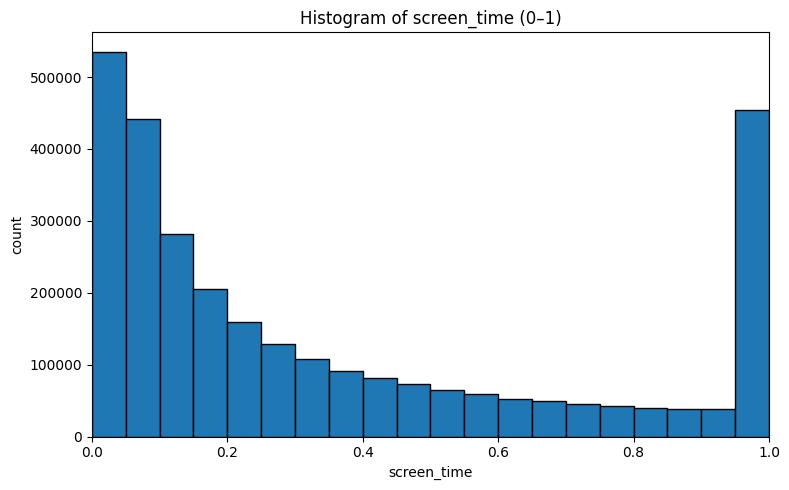

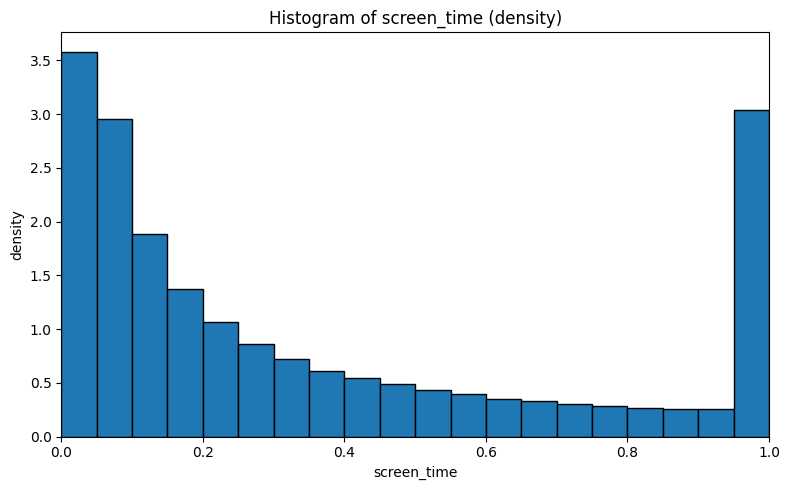

In [22]:
joined["screen_time"] = joined["overlap_s"] / joined["show_duration_s"]


# 1) Làm sạch screen_time trong [0,1]
st = pd.to_numeric(joined["screen_time"], errors="coerce")
st = st[(st >= 0) & (st <= 1)].dropna()

print("Tóm tắt screen_time:")
print(st.describe(percentiles=[.25,.5,.75,.9,.95,.99]))

# 2) Histogram (0→1, bước 0.05)
plt.figure(figsize=(8,5))
bins = np.linspace(0, 1, 21)  # 0.00, 0.05, ..., 1.00
plt.hist(st, bins=bins, edgecolor="black", density=False)
plt.title("Histogram of screen_time (0–1)")
plt.xlabel("screen_time")
plt.ylabel("count")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# (tuỳ chọn) Histogram dạng mật độ
plt.figure(figsize=(8,5))
plt.hist(st, bins=bins, edgecolor="black", density=True)
plt.title("Histogram of screen_time (density)")
plt.xlabel("screen_time")
plt.ylabel("density")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


In [23]:
joined.columns

Index(['user_id', 'tv_show_id', 'vsetv_id', 'start_time_view', 'end_time_view',
       'duration_view', 'seg_start', 'seg_end', 'overlap_s', 'show_duration_s',
       'view_id', 'seg_idx', 'screen_time'],
      dtype='object')

## Loai cac chuong trinh ma co screen time thap
- Chương trình ngắn → cần tỷ lệ cao (nếu không rất dễ “xem lướt”).
- Chương trình dài → tỷ lệ có thể thấp hơn, nhưng vẫn cần số phút tối thiểu đủ lớn.

- Theo phần trăm (tỷ lệ) – ngưỡng phụ thuộc show_duration_minutes:
    - < 15 phút → screen_time ≥ 0.80
    - 15–30 → screen_time ≥ 0.70
    - 30–60 → screen_time ≥ 0.60
    - 60–120 → screen_time ≥ 0.50
    - > 120 → screen_time ≥ 0.50

In [24]:
import numpy as np
import pandas as pd

def apply_adaptive_screen_time_filter(
    df: pd.DataFrame,
    st_col: str = "screen_time",
    ovl_s_col: str = "overlap_s",
    showdur_s_col: str = "show_duration_s",
):
    # Kiểm tra cột bắt buộc
    required = {st_col, ovl_s_col, showdur_s_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Thiếu cột: {missing}")

    out = df.copy()

    # Làm sạch nhẹ
    out[st_col] = pd.to_numeric(out[st_col], errors="coerce")
    out[ovl_s_col] = pd.to_numeric(out[ovl_s_col], errors="coerce")
    out[showdur_s_col] = pd.to_numeric(out[showdur_s_col], errors="coerce")

    # chuẩn bị phút
    dur_min = out[showdur_s_col] / 60.0
    ovl_min = out[ovl_s_col] / 60.0

    # ngưỡng
    pct_thresh = np.select(
        [   (dur_min < 10),
            (dur_min >= 10) & (dur_min < 30),
            (dur_min >= 30) & (dur_min < 60),
            (dur_min >= 60) & (dur_min < 90),
            (dur_min >= 90) & (dur_min < 180),
            (dur_min >= 180) & (dur_min < 300),
            (dur_min >= 300)
        ],
        [ 0.8, 0.7, 0.50, 0.3, 0.25, 0.2, 0.1],
    )
    cond_pct = out[st_col] >= pct_thresh

    min_minutes = np.select(
        [   (dur_min < 30),
            (dur_min >= 30) & (dur_min < 60),
            (dur_min >= 60) & (dur_min < 120),
            (dur_min >= 120),
        ],
        [15, 20, 30, 40],
    )
    cond_abs = ovl_min >= min_minutes

    # keep nếu đạt 1 trong 2 điều kiện
    keep = cond_pct | cond_abs

    # chặn case dữ liệu lỗi
    keep &= out[showdur_s_col] > 0
    keep &= out[st_col].between(0, 1, inclusive="both")

    out["keep"] = keep
    eligible = out[out["keep"]].copy()
    return eligible, out


eligible, joined_with_flag = apply_adaptive_screen_time_filter(joined)

rate = joined_with_flag["keep"].mean() * 100
print(f"Kept: {rate:.2f}%  |  rows kept: {eligible.shape[0]:,} / {joined_with_flag.shape[0]:,}")

# đảm bảo mỗi user đủ ≥5 show
enough_users = eligible.groupby("user_id")["tv_show_id"].nunique().ge(5).mean() * 100
print(f"Tỉ lệ user còn ≥5 chương trình: {enough_users:.2f}%")


Kept: 39.92%  |  rows kept: 1,193,591 / 2,990,107
Tỉ lệ user còn ≥5 chương trình: 98.61%


In [25]:
total_users = eligible["user_id"].nunique()
print(f"Tổng user: {total_users:,}")

Tổng user: 4,876


In [26]:
eligible.shape

(1193591, 14)

In [27]:
eligible.columns

Index(['user_id', 'tv_show_id', 'vsetv_id', 'start_time_view', 'end_time_view',
       'duration_view', 'seg_start', 'seg_end', 'overlap_s', 'show_duration_s',
       'view_id', 'seg_idx', 'screen_time', 'keep'],
      dtype='object')

In [28]:
eligible.head(5)

,user_id,tv_show_id,vsetv_id,start_time_view,end_time_view,duration_view,seg_start,seg_end,overlap_s,show_duration_s,view_id,seg_idx,screen_time,keep
8,1.344593e+19,6600437,353,2020-03-09 08:10:10,2020-03-09 09:17:14,4024,2020-03-09 08:10:10,2020-03-09 09:17:14,4024,7200,16,0,0.558889,True
10,1.260258e+19,6600437,353,2020-03-09 08:12:25,2020-03-09 09:58:20,6355,2020-03-09 08:12:25,2020-03-09 09:30:00,4655,7200,18,0,0.646528,True
22,1.050707e+19,6600437,353,2020-03-09 15:57:38,2020-03-09 16:31:20,2022,2020-03-09 16:00:00,2020-03-09 16:31:20,1880,7200,124,0,0.261111,True
39,4.597275e+18,6600437,353,2020-03-09 17:20:09,2020-03-09 17:57:57,2268,2020-03-09 17:20:09,2020-03-09 17:57:57,2268,7200,141,0,0.315000,True
44,2.319255e+18,6600437,353,2020-03-09 19:41:18,2020-03-09 20:51:33,4215,2020-03-09 20:00:00,2020-03-09 20:51:33,3093,7800,178,0,0.396538,True


# Add session
- Nhóm các lượt xem liên tiếp thành một “phiên” (session) theo khoảng trống thời gian (ví dụ >45’ thì coi là phiên mới).
- Hiểu đúng ngữ cảnh hành vi: trong một phiên người dùng thường có cùng mục đích (xem thời sự tối, xem phim tối CN…), nên tín hiệu liên quan – khác với các lượt xem rời rạc ở các ngày khác.
- Tạo đặc trưng mạnh theo phiên: tổng thời lượng, số kênh/chương trình khác nhau, chương trình cuối phiên, tần suất chuyển kênh, thời gian trong ngày của phiên…
- Lấy mẫu dữ liệu thông minh: chọn positive/negative trong/khác phiên cho học xếp hạng hoặc học tương phản.
- Tránh rò rỉ thời gian khi chia dữ liệu: split train/val theo mốc thời gian/tuần, còn session_id giúp bạn đảm bảo không cắt đôi một phiên.
- Làm input cho mô hình chuỗi (RNN/Transformer): mỗi phiên là một sequence ngắn gọn, ít nhiễu “zapping”.

In [29]:
# 1) Gắn session theo gap thời gian (mặc định: 45 phút)
def add_sessions(df: pd.DataFrame,
                 user_col="user_id",
                 ts_col="start_time_view",
                 gap_min: int = 45,
                 session_col="session_id") -> pd.DataFrame:
    out = df.copy()
    out[ts_col] = pd.to_datetime(out[ts_col], errors="raise")
    out = out.sort_values([user_col, ts_col], kind="mergesort")
    gap_s = out.groupby(user_col)[ts_col].diff().dt.total_seconds().fillna(np.inf)
    new_sess = (gap_s > gap_min * 60).astype(int)
    out[session_col] = new_sess.groupby(out[user_col]).cumsum()
    return out

In [30]:
eligible = add_sessions(eligible, user_col="user_id",
                           ts_col="start_time_view", gap_min=45)

print(f"users: {eligible['user_id'].nunique():,} | "
      f"sessions: {eligible[['user_id','session_id']].drop_duplicates().shape[0]:,}")

users: 4,876 | sessions: 711,192


# Tao output train/val

In [31]:
def split_by_weeks(df: pd.DataFrame,
                   ts_col="start_time_view",
                   train_weeks=(11, 24),
                   val_weeks=(25, 30)) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = df.copy()
    out[ts_col] = pd.to_datetime(out[ts_col], errors="raise")
    iso = out[ts_col].dt.isocalendar()
    out["iso_year"] = iso.year
    out["iso_week"] = iso.week

    tr_lo, tr_hi = train_weeks
    va_lo, va_hi = val_weeks

    train = out[(out["iso_week"] >= tr_lo) & (out["iso_week"] <= tr_hi)].copy()
    val   = out[(out["iso_week"] >= va_lo) & (out["iso_week"] <= va_hi)].copy()
    return train, val

In [32]:
train_df, val_df = split_by_weeks(eligible,
                                  ts_col="start_time_view",
                                  train_weeks=(11,26),
                                  val_weeks=(27,30))

print(f"train: {train_df.shape} | val: {val_df.shape}")

train: (931766, 17) | val: (261825, 17)


In [33]:

# ---- Robust project root detection ----
def get_project_root() -> Path:
    # 1) Script mode
    if "__file__" in globals():
        return Path(__file__).resolve().parents[1]  # src/.. -> project root
    # 2) Notebook/REPL: dò từ CWD ngược lên cho đến khi thấy both 'data' và 'src'
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data").exists() and (p / "src").exists():
            return p
    # 3) Fallback: dùng CWD
    return cwd

PROJECT_ROOT = get_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "clean"   # hoặc "clean" nếu bạn muốn
DATA_DIR.mkdir(parents=True, exist_ok=True)

OUT_TRAIN = DATA_DIR / "train.parquet"
OUT_VAL   = DATA_DIR / "val.parquet"

train_df.to_parquet(OUT_TRAIN, index=False)
val_df.to_parquet(OUT_VAL, index=False)

In [34]:
out_train = DATA_DIR / "train.parquet"
out_val   = DATA_DIR / "val.parquet"

train_df.to_parquet(out_train, index=False)
val_df.to_parquet(out_val, index=False)

# Xu ly data test

In [35]:
import pandas as pd

def load_test_meta(path=r"/content/export_arh_31-42-final.csv"):
    meta = pd.read_csv(path)
    meta = meta.rename(columns={"channel_id": "vsetv_id"})
    # lọc 0
    meta = meta[pd.to_numeric(meta["tv_show_id"], errors="coerce").fillna(0).astype(int) != 0].copy()

    # chuẩn hoá thời gian (nếu cần)
    meta["start_time"] = pd.to_datetime(meta["start_time"], dayfirst=True, errors="coerce")
    meta["duration"] = pd.to_numeric(meta["duration"], errors="coerce")
    meta["prog_end"] = meta["start_time"] + pd.to_timedelta(meta["duration"], unit="s")

    # từ điển tra cứu thuộc tính
    cols = ["tv_show_id","tv_show_title","tv_show_category","tv_show_genre_1","tv_show_genre_2","tv_show_genre_3","vsetv_id"]
    meta_lookup = meta[cols].dropna(subset=["tv_show_id"]).drop_duplicates("tv_show_id")
    return meta, meta_lookup

test_meta, test_lookup = load_test_meta()
print("Số tv_show_id (test, ≠0):", test_lookup.shape[0])


/tmp/ipython-input-1603879231.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv(path)


Số tv_show_id (test, ≠0): 6636


In [36]:
test_lookup.shape

(6636, 7)

In [37]:
test_lookup.head(5)

,tv_show_id,tv_show_title,tv_show_category,tv_show_genre_1,tv_show_genre_2,tv_show_genre_3,vsetv_id
0,20088,'Завтрак с 1+1'. Информационно-развлекательная...,Развлечения,информация (комплексная),NaN,NaN,3
1,2400480,ТСН.,Инфо,общество и политика,NaN,NaN,3
9,700382,"'Рассмеши комика', 16 сезон, 7 и 8 эп.",Развлечения,юмор,NaN,NaN,3
14,10003015,"Т/с 'Папа Дэн', 1 с.",Сериалы,драма,комедия,мелодрама,3
15,90071145,Х/ф 'Шерлок: Этюд в розовых тонах'.,Фильмы,детектив,NaN,NaN,3


In [38]:
out_test   = DATA_DIR / "test.parquet"

test_lookup.to_parquet(out_test, index=False)

Tạo metadata


In [39]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

def create_clean_metadata():
    source_files = [
        "export_arh_11-20-final.csv",
        "export_arh_21-30-final.csv",
    ]

    output_dir = 'data/processed'
    output_path = f'{output_dir}/program_metadata_full.parquet'
    os.makedirs(output_dir, exist_ok=True)

    # đọc và Gộp dữ liệu
    dfs = []
    for f in source_files:
        if os.path.exists(f):
            dfs.append(pd.read_csv(f, dtype=str))
        else:
            print(f"Không tìm thấy {f}")

    if not dfs:
        return

    full_df = pd.concat(dfs, ignore_index=True)
    cols_to_keep = [
        'tv_show_id', 'tv_show_title',
        'channel_id', 'channel_title',
        'tv_show_genre_1', 'tv_show_genre_2', 'tv_show_genre_3',
        'year_of_production',
        'director', 'actors'
    ]

    # chỉ giữ các cột tồn tại
    existing_cols = [c for c in cols_to_keep if c in full_df.columns]
    meta_df = full_df[existing_cols].copy()

    # làm sạch dữ liệu
    print("   -> Đang làm sạch và loại bỏ trùng lặp...")

    # chuyển tv_show_id sang số để lọc
    meta_df['tv_show_id'] = pd.to_numeric(meta_df['tv_show_id'], errors='coerce').fillna(0).astype(int)
    meta_df = meta_df[meta_df['tv_show_id'] != 0] # Bỏ ID rác

    # xử lý cột year
    if 'year_of_production' in meta_df.columns:
        meta_df['year_of_production'] = pd.to_numeric(meta_df['year_of_production'], errors='coerce')

    # đếm số lượng giá trị không phải NaN/Null trong mỗi dòng
    meta_df['info_score'] = meta_df.notna().sum(axis=1)

    # sắp xếp ưu tiên: ID -> Nhiều thông tin nhất -> Dòng xuất hiện sau cùng (thường mới hơn)
    meta_df = meta_df.sort_values(by=['tv_show_id', 'info_score'], ascending=[True, False])

    # giữ lại dòng đầu tiên (tốt nhất) cho mỗi ID
    meta_unique = meta_df.drop_duplicates(subset=['tv_show_id'], keep='first')
    meta_unique = meta_unique.drop(columns=['info_score'])

    print(f"   -> Tổng số chương trình duy nhất (Unique Nodes): {len(meta_unique)}")

    # lưu file
    meta_unique.to_parquet(output_path, index=False)

    # check
    print(meta_unique[['tv_show_id', 'year_of_production', 'tv_show_genre_1', 'actors']].head())

    # kiểm tra các trường quan trọng có bị null nhiều không
    print("\n--- Thống kê dữ liệu còn thiếu ---")
    print(meta_unique.isnull().sum())

create_clean_metadata()

   -> Đang làm sạch và loại bỏ trùng lặp...
   -> Tổng số chương trình duy nhất (Unique Nodes): 8234
         tv_show_id  year_of_production           tv_show_genre_1  \
10            20088                 NaN  информация (комплексная)   
16761         30066                 NaN                      юмор   
18897         30085                 NaN                      юмор   
1265430       52641                 NaN                       NaN   
1848473       90054              1994.0                     драма   

                                                   actors  
10                                                    NaN  
16761                   Михаил Галустян, Сергей Светлаков  
18897    Фёдор Добронравов, Сергей Дорогов, Андрей Кайков  
1265430                                               NaN  
1848473       Дэвид Боу, Уилфорд Бримли, Мэри Бет МакДона  

--- Thống kê dữ liệu còn thiếu ---
tv_show_id               0
tv_show_title            0
channel_id               0
channel

In [41]:
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-$(torch.__version__).html -q
!pip install sentence-transformers -q
!pip install scikit-learn -q

/bin/bash: line 1: torch.__version__: command not found
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.2 MB/s eta 0:00:00


In [42]:
# tạo dữ liệu và huấn luyện
#!pip install scikit-learn -q
#!pip install sentence-transformers -q
#!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-$(torch.__version__).html -q

import pandas as pd
import numpy as np
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from torch_geometric.nn import GATConv
from torch_geometric.utils import negative_sampling
from sklearn.model_selection import train_test_split as sk_train_test_split

"""
Cơ chế hoạt động:
1.  **Knowledge Graph Construction:** - Chuyển đổi metadata (program, actor, genre, director...) thành một đồ thị tri thức.
    - Tạo danh sách cạnh và ánh xạ thực thể.
2.  **Feature Engineering (SBERT):** - Sử dụng Sentence-BERT để mã hóa thông tin văn bản của program thành vector ngữ nghĩa.
    - Vector này được dùng làm đặc trưng khởi tạo cho node program trong đồ thị.
3.  **Graph Learning (KGAT):** - Huấn luyện mô hình GNN với cơ chế Attention (GAT) để học biểu diễn (embedding) cho từng node.
    - Mô hình học cách lan truyền thông tin từ actor/genre sang program.
4.  **Candidate Generation:** - Sử dụng embedding đã học để tìm kiếm lân cận.
    - Gợi ý các program có embedding gần nhất với rogram user vừa xem.
"""

METADATA_PATH = 'data/processed/program_metadata_full.parquet'
KG_DIR = 'data/kg'
SBERT_PATH = 'data/interim/sbert_embeddings.npy'
OUTPUT_PATH = "data/candidates/item_kg_emb.npy"
# tham số
EMBED_DIM = 128
EPOCHS = 200
LR = 0.01

os.makedirs(KG_DIR, exist_ok=True)
os.makedirs('data/interim', exist_ok=True)
os.makedirs('data/candidates', exist_ok=True)

# TẠO SBERT EMBEDDINGS
    """
    Kiểm tra và tạo file SBERT Embeddings nếu chưa có.
    - Input: Metadata (Title, Actor, Genre...).
    - Process: Kết hợp văn bản -> Mã hóa bằng pre-trained SBERT model.
    - Output: File .npy chứa ma trận vector đặc trưng.
    """
def ensure_sbert_exists():
    if os.path.exists(SBERT_PATH):
        return

    try:
        df = pd.read_parquet(METADATA_PATH).fillna('')
    except FileNotFoundError:
        return

    model = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')

    # Kết hợp text để mã hóa
    df['text'] = df.apply(lambda x: f"{x['tv_show_title']} {x['actors']} {x['director']} {x['tv_show_genre_1']}", axis=1)
    embeddings = model.encode(df['text'].tolist(), show_progress_bar=True, batch_size=64)

    np.save(SBERT_PATH, embeddings)

# XÂY DỰNG ĐỒ THỊ TRI THỨC
    """
    Xây dựng cấu trúc đồ thị từ metadata.
    - Input: metadata dataframe.
    - Process:
        - Tạo ID duy nhất cho mỗi thực thể.
        - Tạo danh sách cạnh kết nối program với các thực thể liên quan.
    - Output:
        - kg_edge_index.pt: Tensor chứa danh sách cạnh.
        - kg_entity_map.json: Từ điển ánh xạ ID thực thể.
    """
def ensure_kg_exists():
    if os.path.exists(f"{KG_DIR}/kg_edge_index.pt"):
        return

    try:
        df_meta = pd.read_parquet(METADATA_PATH).fillna('')
    except: return

    entity_map = {}
    edges = []

    def get_id(name, prefix):
        clean = str(name).strip().lower()
        if not clean or clean == 'nan': return None
        key = f"{prefix}_{clean}"
        if key not in entity_map: entity_map[key] = len(entity_map)
        return entity_map[key]

    for _, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc="Building KG"):
        prog_id = get_id(row['tv_show_id'], 'p')
        if prog_id is None: continue

        # Actor
        for actor in str(row.get('actors', '')).split(','):
            aid = get_id(actor, 'a')
            if aid: edges.extend([[prog_id, aid], [aid, prog_id]])
        # Genre
        for col in ['tv_show_genre_1', 'tv_show_genre_2']:
            gid = get_id(row.get(col, ''), 'g')
            if gid: edges.extend([[prog_id, gid], [gid, prog_id]])
        # Director & Channel
        did = get_id(row.get('director', ''), 'd')
        if did: edges.extend([[prog_id, did], [did, prog_id]])
        cid = get_id(row.get('channel_id', ''), 'c')
        if cid: edges.extend([[prog_id, cid], [cid, prog_id]])

    if not edges:
        return

    edge_index = torch.LongTensor(edges).t().contiguous()
    torch.save(edge_index, f"{KG_DIR}/kg_edge_index.pt")
    with open(f"{KG_DIR}/kg_entity_map.json", 'w') as f: json.dump(entity_map, f)

# MÔ HÌNH KGAT
def get_node_mappings(entity_map):
    p_keys = sorted([k for k in entity_map if k.startswith('p_')], key=lambda x: entity_map[x])
    return [entity_map[k] for k in p_keys], [k.split('_')[1] for k in p_keys]

class KGGNNEncoder(nn.Module):
    def __init__(self, num_ent, emb_dim, sbert, p_idx):
        super().__init__()
        self.emb = nn.Embedding(num_ent, emb_dim)
        nn.init.xavier_uniform_(self.emb.weight.data)

        # Feature Fusion
        sbert = torch.tensor(sbert).float()
        if sbert.shape[1] != emb_dim:
            self.proj = nn.Linear(sbert.shape[1], emb_dim)
            sbert = self.proj(sbert)

        self.emb.weight.data[p_idx] = sbert.clone().detach()
        self.emb.weight.requires_grad = True

        self.conv1 = GATConv(emb_dim, emb_dim, heads=4, concat=False)
        self.conv2 = GATConv(emb_dim, emb_dim, heads=4, concat=False)

    def forward(self, edge_index):
        x = self.emb.weight
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

# HUẤN LUYỆN MÔ HÌNH
    """
    Quy trình huấn luyện mô hìnhtrên KG.
    - Load Data: đồ thị, map, SBERT.
    - Split: chia tập cạnh train/test.
    - Loop: huấn luyện với positive (cạnh thật) và negative sampling (cạnh giả).
    - Save: lưu embedding cuối cùng của các node rogram.
    """
def train_kgat():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # load Data
    edge_index = torch.load(f"{KG_DIR}/kg_edge_index.pt").to(device)
    with open(f"{KG_DIR}/kg_entity_map.json") as f: entity_map = json.load(f)
    sbert = np.load(SBERT_PATH)

    p_idx, p_ids = get_node_mappings(entity_map)
    sbert_p = sbert[:len(p_idx)] # Cắt đúng số lượng program

    model = KGGNNEncoder(len(entity_map), EMBED_DIM, sbert_p, p_idx).to(device)
    opt = optim.Adam(model.parameters(), lr=LR)
    crit = nn.BCEWithLogitsLoss()

    # chia cạnh
    all_idx = np.arange(edge_index.size(1))
    train_idx, _ = sk_train_test_split(all_idx, train_size=0.9, random_state=42)
    train_edges = edge_index[:, train_idx].to(device)

    # train
    print(f"   -> Training on {len(train_idx)} edges for {EPOCHS} epochs...")
    for ep in range(1, EPOCHS + 1):
        model.train(); opt.zero_grad()

        z = model(train_edges)
        # positive sampling
        pos = (z[train_edges[0]] * z[train_edges[1]]).sum(dim=1)
        # negative sampling
        neg_edges = negative_sampling(edge_index, num_nodes=len(entity_map), num_neg_samples=len(train_idx)).to(device)
        neg = (z[neg_edges[0]] * z[neg_edges[1]]).sum(dim=1)

        label = torch.cat([torch.ones_like(pos), torch.zeros_like(neg)])
        pred = torch.cat([pos, neg])

        loss = crit(pred, label)
        loss.backward()
        opt.step()

        if ep % 10 == 0: print(f"      Epoch {ep}: Loss {loss.item():.4f}")
    # SAVE
    model.eval()
    with torch.no_grad(): final_emb = model(edge_index).cpu().numpy()

    p_emb = final_emb[p_idx]
    np.save(OUTPUT_PATH, p_emb)

    with open(OUTPUT_PATH.replace('.npy', '.json'), 'w') as f:
        json.dump({pid: i for i, pid in enumerate(p_ids)}, f)

if __name__ == "__main__":
    ensure_sbert_exists()
    ensure_kg_exists()
    train_kgat()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/129 [00:00<?, ?it/s]

Building KG: 100%|██████████| 8234/8234 [00:00<00:00, 18054.31it/s]


   -> Training on 96474 edges for 200 epochs...
      Epoch 10: Loss 0.6178
      Epoch 20: Loss 0.5922
      Epoch 30: Loss 0.5696
      Epoch 40: Loss 0.5490
      Epoch 50: Loss 0.5282
      Epoch 60: Loss 0.5149
      Epoch 70: Loss 0.5009
      Epoch 80: Loss 0.5100
      Epoch 90: Loss 0.4894
      Epoch 100: Loss 0.4668
      Epoch 110: Loss 0.4511
      Epoch 120: Loss 0.4440
      Epoch 130: Loss 0.4387
      Epoch 140: Loss 0.4343
      Epoch 150: Loss 0.4385
      Epoch 160: Loss 0.4300
      Epoch 170: Loss 0.4227
      Epoch 180: Loss 0.4189
      Epoch 190: Loss 0.4152
      Epoch 200: Loss 0.4104


In [43]:
"""
Sử dụng Item Embeddings đã được huấn luyện từ mô hình GNN (KGAT) để tìm kiếm các chương trình tương đồng nhất cho mỗi người dùng.

Cơ chế hoạt động:
1.  **Data Loading:** Tải ma trận embedding (.npy) và bản đồ ánh xạ id (.json).
2.  **Normalization:** Chuẩn hóa L2 các vector embedding để phép nhân ma trận trở thành cosine similarity.
3.  **Seed Identification:** Xác định chương trình xem cuối cùng của mỗi user làm "hạt giống".
4.  **Nearest Neighbor Search:**
    - Với mỗi user, lấy vector của item hạt giống.
    - Tính độ tương đồng cosine với toàn bộ kho item.
    - Lấy Top-K item gần nhất làm ứng viên gợi ý.
5.  **Export:** Lưu danh sách ứng viên ra file Parquet.
"""
import os
import numpy as np
import pandas as pd
import json
import torch
from tqdm import tqdm

BASE_DIR = os.getcwd()
EMB_PATH = os.path.join(BASE_DIR, "data/candidates/item_kg_emb.npy")
MAP_PATH = os.path.join(BASE_DIR, "data/candidates/item_kg_emb.json")
TRAIN_PATH = os.path.join(BASE_DIR, "data/clean/train.parquet")
OUTPUT_PATH = os.path.join(BASE_DIR, "data/candidates/kg_embedding_candidates.parquet")

    """
    Hàm chính thực thi quy trình tạo ứng viên từ KG Embeddings.
    Bao gồm các bước kiểm tra file, load dữ liệu, tính toán tương đồng và lưu kết quả.
    """
def debug_and_run():

    files = {"Embedding": EMB_PATH, "Map JSON": MAP_PATH, "Train Data": TRAIN_PATH}
    missing = []
    for name, path in files.items():
        if os.path.exists(path):
            size = os.path.getsize(path) / 1024 # KB
        else:
            missing.append(name)

    if missing:
        return

    # load data
    try:
        # load NPY
        emb_matrix = np.load(EMB_PATH)

        # load json map
        with open(MAP_PATH, 'r') as f:
            id_map_raw = json.load(f)
        # chuẩn hóa Map
        id_map = {str(k).replace('.0', ''): v for k, v in id_map_raw.items()}
        index_to_id = {v: k for k, v in id_map.items()}

        # load train data
        df_train = pd.read_parquet(TRAIN_PATH)

    except Exception as e:
        return

    # tạo ứng viên

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tensor_emb = torch.tensor(emb_matrix, dtype=torch.float32).to(device)
    tensor_emb = torch.nn.functional.normalize(tensor_emb, p=2, dim=1)

    # Lấy item xem cuối cùng của mỗi user
    last_views = df_train.sort_values('start_time_view').groupby('user_id').last().reset_index()

    candidates = []
    TOP_K = 50
    BATCH_SIZE = 100

    user_batches = [last_views[i:i + BATCH_SIZE] for i in range(0, len(last_views), BATCH_SIZE)]

    # vòng lặp tìm
    for batch in tqdm(user_batches, desc="Searching"):
        seed_indices = []
        batch_users = []

        for _, row in batch.iterrows():
            raw_id = str(row['tv_show_id'])
            clean_id = raw_id.replace('.0', '')

            if clean_id in id_map:
                seed_indices.append(id_map[clean_id])
                batch_users.append(row['user_id'])

        if not seed_indices: continue

        # tính toán tương đồng
        seed_vecs = tensor_emb[seed_indices] # (Batch, Dim)
        scores = torch.matmul(seed_vecs, tensor_emb.t()) # (Batch, Num_Items)

        # lấy Top K
        top_vals, top_idxs = torch.topk(scores, k=TOP_K + 1, dim=1)

        # chuyển về CPU
        top_idxs = top_idxs.cpu().numpy()
        top_vals = top_vals.cpu().numpy()

        # lưu kết quả
        for i, user_id in enumerate(batch_users):
            seed_idx = seed_indices[i]
            rank = 1
            for j, item_idx in enumerate(top_idxs[i]):
                if item_idx == seed_idx: continue
                if rank > TOP_K: break

                rec_id_str = index_to_id[item_idx]

                candidates.append({
                    'user_id': user_id,
                    'tv_show_id': float(rec_id_str),
                    'score': float(top_vals[i][j]),
                    'rank': rank
                })
                rank += 1

    if candidates:
        df_cand = pd.DataFrame(candidates)
        os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
        df_cand.to_parquet(OUTPUT_PATH, index=False)
    else:
        print("\nKhông tìm thấy ứng viên nào.")

debug_and_run()

Searching: 100%|██████████| 49/49 [00:01<00:00, 47.98it/s]


content-based


In [44]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from tqdm import tqdm
import os
from pathlib import Path

METADATA_PATH = "data/processed/program_metadata_full.parquet"
TRAIN_PATH = "data/clean/train.parquet"
OUTPUT_PATH = "data/candidates/content_profile.parquet"
TOP_K = 100
W_TITLE = 0.7
W_META = 0.3

def run_content_based_weighted():
    """
    Quy trình:
    1. Tải dữ liệu Metadata và Train Log.
    2. [Item Features] Tạo ma trận TF-IDF cho Title và Metadata.
    3. [User Profile] Tính toán vector đại diện cho User dựa trên lịch sử xem có trọng số.
    4. [Scoring] Tính điểm Cosine Similarity và trích xuất Top-K ứng viên.
    5. Lưu kết quả ra file Parquet.
    """
    # 1. LOAD DATA
    try:
        df_meta = pd.read_parquet(METADATA_PATH).fillna('')
        df_train = pd.read_parquet(TRAIN_PATH)
    except FileNotFoundError as e:
        return
    # 2. XÂY DỰNG ITEM FEATURES
    """
   Chuyển đổi thông tin văn bản của chương trình thành vector số học.
    - Xử lý Year Bucket.
    - Gom nhóm các thuộc tính phụ (Genre, Category...) thành chuỗi văn bản.
    - Vector hóa Title và Metadata string bằng TF-IDF.
    - Chuẩn hóa L2 để chuẩn bị cho tính Cosine Similarity.
    """
    # kiểm tra nếu có cột year
    if 'year_of_production' in df_meta.columns:
        def get_year_bucket(y):
            try:
                y = float(y)
                if y >= 2024: return 'year_new'
                if y >= 2020: return 'year_2020s'
                if y >= 2010: return 'year_2010s'
                return 'year_old'
            except: return 'year_unknown'
        df_meta['year_bucket'] = df_meta['year_of_production'].apply(get_year_bucket)
    else:
        df_meta['year_bucket'] = ''

    # danh sách các cột mong muốn
    wanted_cols = [
        'tv_show_category',
        'channel_title',
        'year_bucket',
        'tv_show_genre_1',
        'tv_show_genre_2',
        'tv_show_genre_3'
    ]

    # khởi tạo chuỗi rỗng
    df_meta['meta_str'] = ""

    for col in wanted_cols:
        if col in df_meta.columns:
            # dồn chuỗi
            df_meta['meta_str'] = df_meta['meta_str'] + " " + df_meta[col].astype(str).fillna('')
        else:
            print(f"Thiếu cột '{col}', bỏ qua.")

    df_meta['meta_str'] = df_meta['meta_str'].str.lower().str.strip()
    title_col = 'tv_show_title' if 'tv_show_title' in df_meta.columns else 'title'
    if title_col not in df_meta.columns:
        return

    tfidf_title = TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=2)
    item_vec_title = tfidf_title.fit_transform(df_meta[title_col].fillna(''))

    # vector hóa metadata
    tfidf_meta = TfidfVectorizer(max_features=5000, binary=True)
    item_vec_meta = tfidf_meta.fit_transform(df_meta['meta_str'])

    # chuẩn hóa L2
    item_vec_title = normalize(item_vec_title, axis=1)
    item_vec_meta = normalize(item_vec_meta, axis=1)

    # map id
    item_ids = df_meta['tv_show_id'].values
    item_id_to_idx = {idn: i for i, idn in enumerate(item_ids)}
    idx_to_item_id = {i: idn for i, idn in enumerate(item_ids)}

    # 3. XÂY DỰNG USER PROFILE
    """
    Tạo vector đại diện cho sở thích của người dùng.
    - Tính trọng số cho mỗi lượt xem (Duration * Time Decay).
    - Tạo ma trận tương tác (User x Item) với giá trị là trọng số đã tính.
    - Nhân ma trận tương tác với ma trận Item Features để ra User Vectors.
      (User_Vec = trung bình trọng số các Item_Vec mà user đã xem).
    """

    # tính weight
    max_date = df_train['start_time_view'].max()
    df_train['days_diff'] = (max_date - df_train['start_time_view']).dt.total_seconds() / (24*3600)
    df_train['time_weight'] = np.exp(-df_train['days_diff'] / 30.0)
    df_train['dur_weight'] = np.log1p(df_train['duration_view'])
    df_train['final_weight'] = df_train['time_weight'] * df_train['dur_weight']

    # map id sang index
    user_ids = df_train['user_id'].unique()
    user_id_to_idx = {uid: i for i, uid in enumerate(user_ids)}
    idx_to_user_id = {i: uid for i, uid in enumerate(user_ids)}

    df_train['item_idx'] = df_train['tv_show_id'].map(item_id_to_idx).fillna(-1).astype(int)
    df_train = df_train[df_train['item_idx'] != -1]
    df_train['user_idx'] = df_train['user_id'].map(user_id_to_idx)

    # ma trận tương tác
    interaction_matrix = sp.csr_matrix(
        (df_train['final_weight'], (df_train['user_idx'], df_train['item_idx'])),
        shape=(len(user_ids), len(item_ids))
    )
    interaction_matrix = normalize(interaction_matrix, norm='l1', axis=1)

    # tính user vectors
    user_vec_title = interaction_matrix.dot(item_vec_title)
    user_vec_meta = interaction_matrix.dot(item_vec_meta)

    # 4. TÍNH ĐIỂM VÀ LẤY CANDIDATES
    """
    Tìm kiếm và xếp hạng ứng viên.
    - Lặp qua từng batch người dùng để tiết kiệm bộ nhớ.
    - Tính Cosine Similarity giữa User Vector và Item Vector (Title & Meta).
    - Tổng hợp điểm: Score = 0.7 * Title_Sim + 0.3 * Meta_Sim.
    - Sử dụng `argpartition` để lấy nhanh Top-K item có điểm cao nhất.
    - Lưu kết quả vào danh sách candidates.
    """

    candidates = []
    batch_size = 1000
    num_users = user_vec_title.shape[0]

    for start_idx in tqdm(range(0, num_users, batch_size), desc="Scoring"):
        end_idx = min(start_idx + batch_size, num_users)

        u_title_batch = user_vec_title[start_idx:end_idx]
        u_meta_batch = user_vec_meta[start_idx:end_idx]

        # tính cosine
        sim_title = u_title_batch.dot(item_vec_title.T).toarray()
        sim_meta = u_meta_batch.dot(item_vec_meta.T).toarray()

        # weighted sum
        final_scores = (W_TITLE * sim_title) + (W_META * sim_meta)

        # lấy k phần tử lớn nhất
        if final_scores.shape[1] > TOP_K:
            top_k_part = np.argpartition(final_scores, -TOP_K, axis=1)[:, -TOP_K:]
        else:
            top_k_part = np.arange(final_scores.shape[1])[None, :]

        rows = np.arange(final_scores.shape[0])[:, None]
        top_k_scores = final_scores[rows, top_k_part]

        # sort lại Top-K để có thứ tự
        sort_indices = np.argsort(-top_k_scores, axis=1)

        for i in range(len(rows)):
            u_idx = start_idx + i
            real_user_id = idx_to_user_id[u_idx]

            sorted_indices = top_k_part[i][sort_indices[i]]
            sorted_scores = top_k_scores[i][sort_indices[i]]

            for rank, (item_idx, score) in enumerate(zip(sorted_indices, sorted_scores)):
                if score > 0:
                    candidates.append({
                        'user_id': real_user_id,
                        'tv_show_id': idx_to_item_id[item_idx],
                        'score': float(score),
                        'rank': rank + 1
                    })

    # 5. LƯU KẾT QUẢ
    if candidates:
        df_cand = pd.DataFrame(candidates)
        os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
        df_cand.to_parquet(OUTPUT_PATH, index=False)
    else:
        print("Không tìm thấy ứng viên nào.")

if __name__ == "__main__":
    run_content_based_weighted()

Thiếu cột 'tv_show_category', bỏ qua.


Scoring: 100%|██████████| 5/5 [00:03<00:00,  1.45it/s]
